In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("data/clean_comments.csv")
df.dropna(inplace=True)
df.head()

,Unnamed: 0,clean_comment,category
0,0,family mormon have never tried explain them th...,2
1,1,buddhism has very much lot compatible with chr...,2
2,2,seriously don say thing first all they won get...,0
3,3,what you have learned yours and only yours wha...,1
4,4,for your own benefit you may want read living ...,2


<Axes: xlabel='category', ylabel='count'>

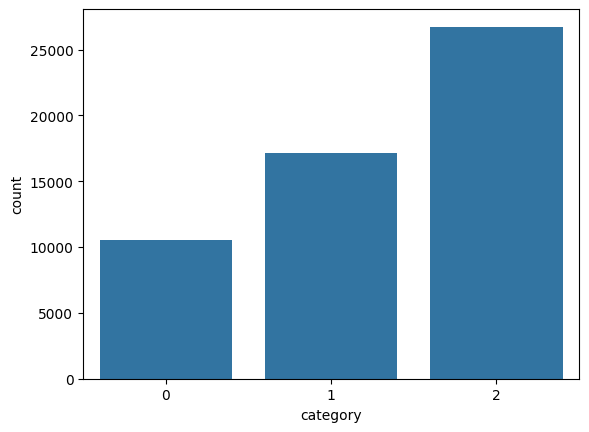

In [7]:
sns.countplot(data=df, x="category")

In [8]:
df['category'].value_counts(normalize=True).mul(100).round(2)

category
2    49.11
1    31.51
0    19.38
Name: proportion, dtype: float64

In [15]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))
df.sample(5)

,Unnamed: 0,clean_comment,category,word_count
5537,5547,they should played this vid the launch event b...,2,12
18568,18629,laos ban bitcoin,1,3
43060,43269,i think the worst year to be born is 1901 you ...,0,30
34398,34571,air india has left air koryo far behind,0,8
30234,30364,whole family did not vote for him last time ta...,2,25


In [16]:
df['word_count'].describe()

count    54153.000000
mean        30.962920
std         53.472445
min          1.000000
25%          8.000000
50%         16.000000
75%         34.000000
max       1331.000000
Name: word_count, dtype: float64

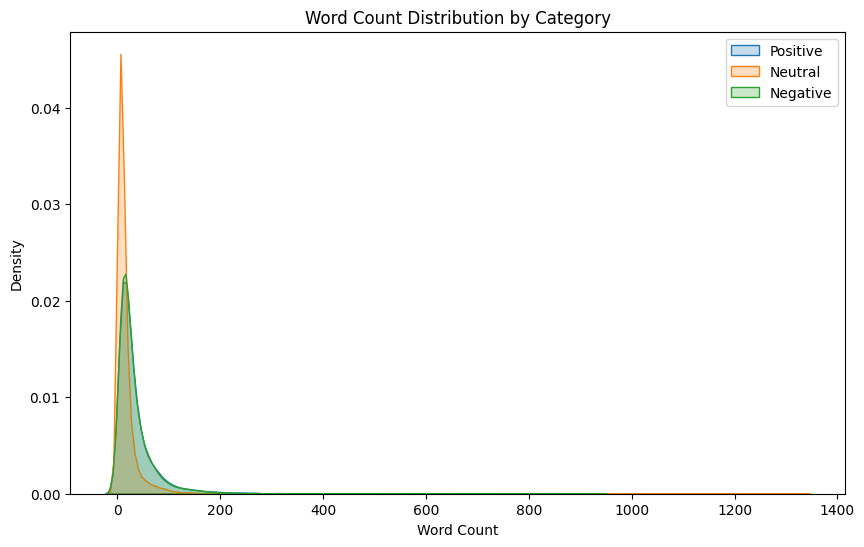

In [18]:
# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot KDE for category 1
sns.kdeplot(df[df['category'] == 2]['word_count'], label='Positive', fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category'] == 1]['word_count'], label='Neutral', fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category'] == 0]['word_count'], label='Negative', fill=True)

# Add title and labels
plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

# Add a legend
plt.legend()

# Show the plot
plt.show()

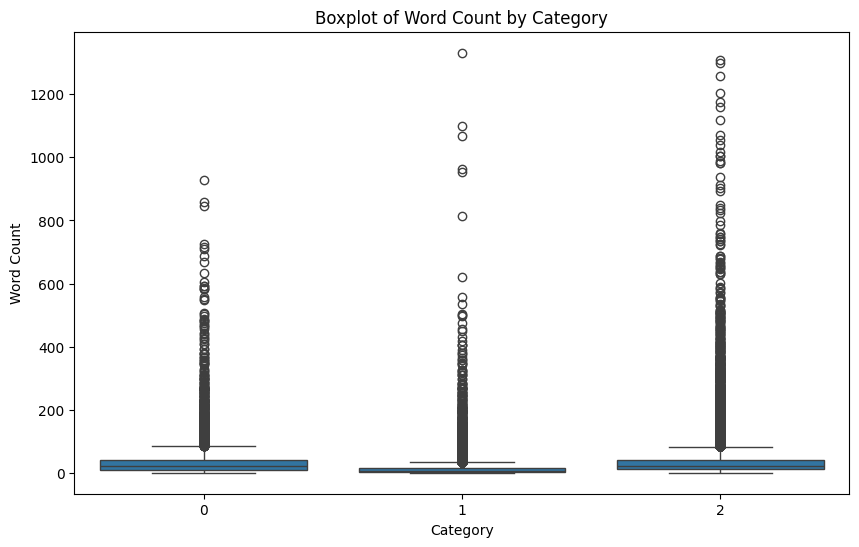

In [19]:
# Create a boxplot for the 'wordcount' column categorized by 'category'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

In [20]:
!pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 4.2 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.6 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 3.1 MB/s  0:00:00

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [regex]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   -------------------- ------------------- 2/4 [click]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

#Number of stopwords in each column
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

     

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vinayak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


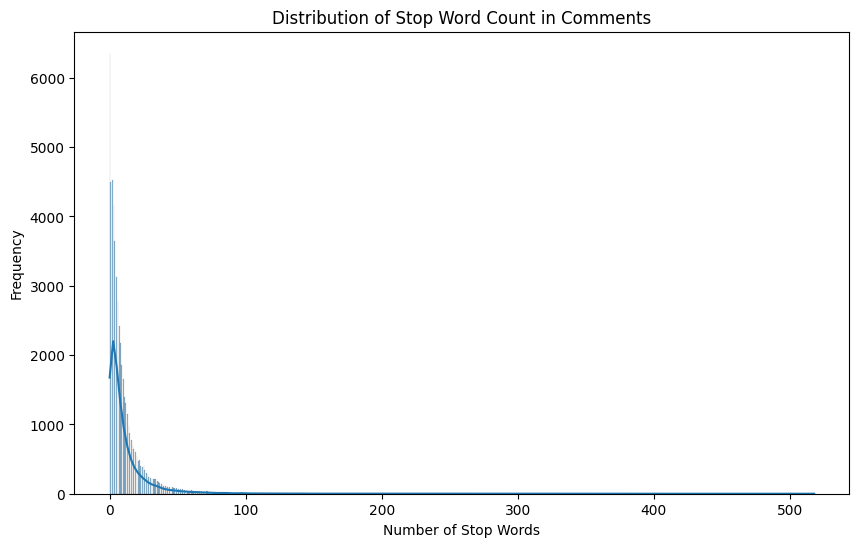

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df['num_stop_words'], kde=True)
plt.title('Distribution of Stop Word Count in Comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()

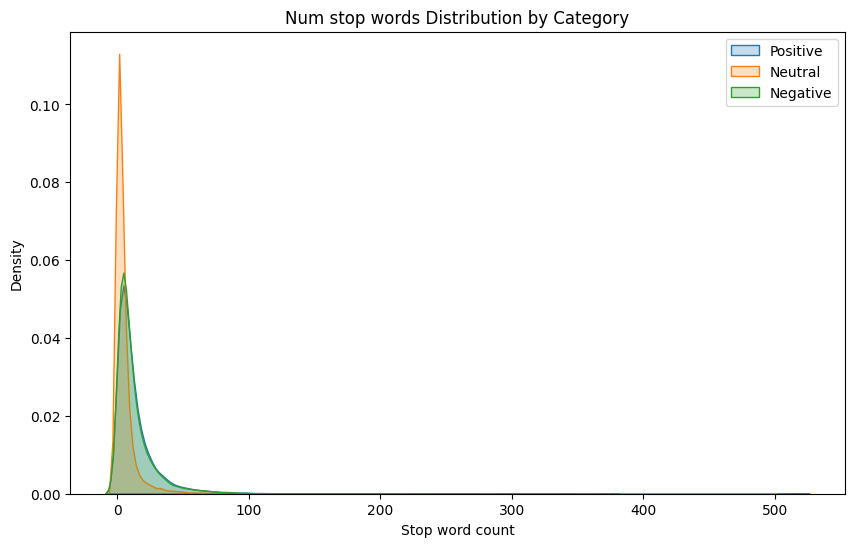

In [26]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df[df['category'] == 2]['num_stop_words'], label='Positive', fill=True)
sns.kdeplot(df[df['category'] == 1]['num_stop_words'], label='Neutral', fill=True)
sns.kdeplot(df[df['category'] == 0]['num_stop_words'], label='Negative', fill=True)

plt.title('Num stop words Distribution by Category')
plt.xlabel('Stop word count')
plt.ylabel('Density')

plt.legend()

plt.show()

In [27]:
from collections import Counter

all_text = ' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)


     

In [28]:
char_frequency_df['character'].values

array([' ', 'e', 't', 'a', 'i', 'o', 'n', 's', 'r', 'h', 'l', 'd', 'u',
       'c', 'm', 'g', 'p', 'y', 'w', 'b', 'f', 'v', 'k', 'j', 'x', '0',
       '1', '2', 'z', 'q', '3', '5', '4', "'", '9', '6', '8', '7', '\\',
       '@'], dtype=object)

C:\Users\Vinayak\AppData\Local\Temp\ipykernel_30008\2018932810.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


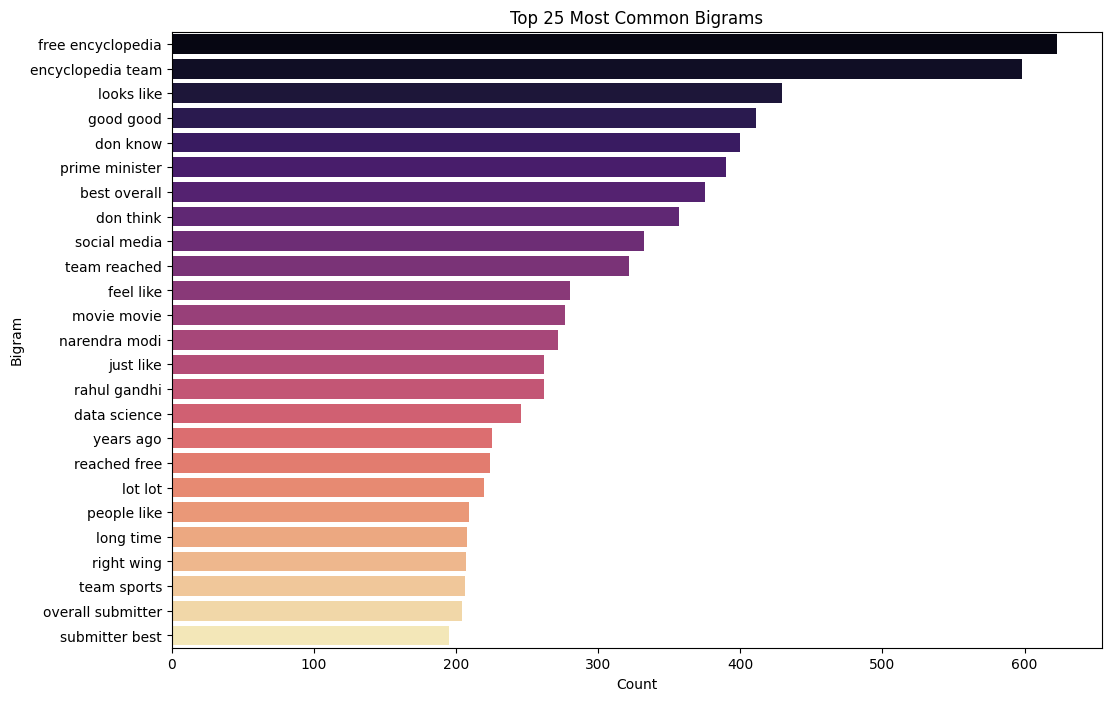

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a function to extract the top 25 bigrams
def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get the top 25 bigrams
top_25_bigrams = get_top_ngrams(df['clean_comment'], 25)

# Convert the bigrams into a DataFrame for plotting
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

# Plot the top 25 bigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()


C:\Users\Vinayak\AppData\Local\Temp\ipykernel_30008\1158422013.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')


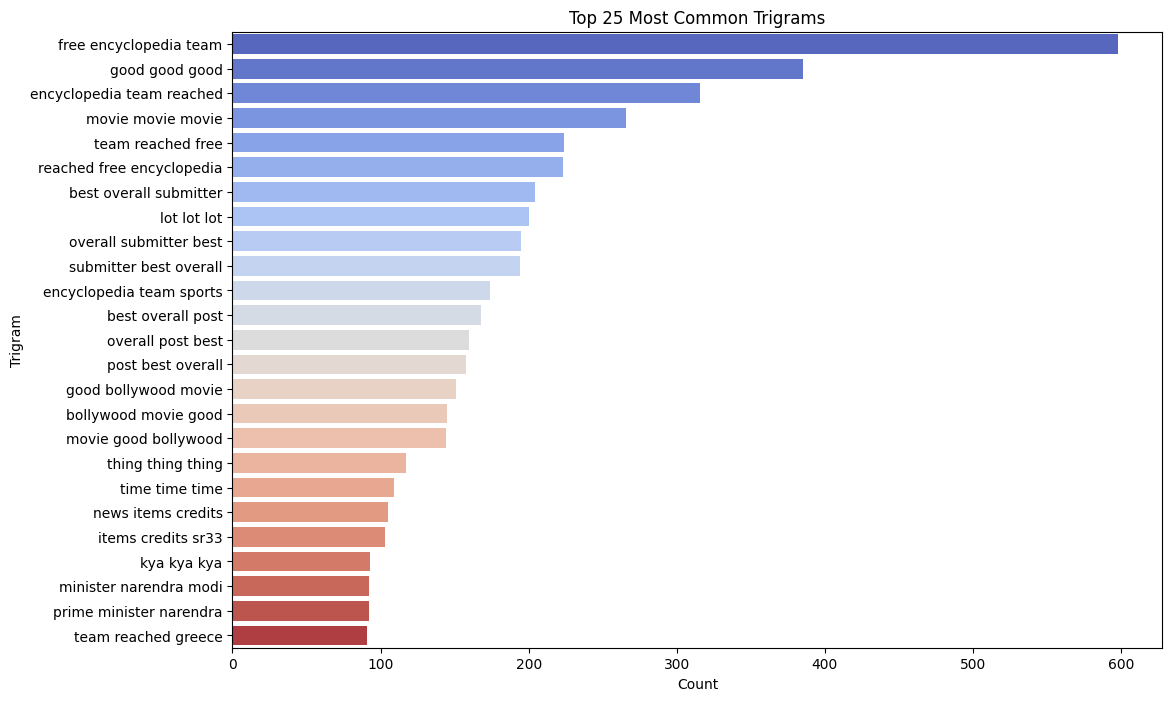

In [30]:
def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

top_25_trigrams = get_top_trigrams(df['clean_comment'], 25)

# Convert the trigrams into a DataFrame for plotting
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=['trigram', 'count'])

# Plot the countplot for the top 25 trigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')
plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [31]:
#Removing the stoppwords

stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}

# Remove stop words from 'clean_comment' column, retaining essential ones
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)



In [32]:
df.head()

,Unnamed: 0,clean_comment,category,word_count,num_stop_words
0,0,family mormon never tried explain still stare ...,2,39,13
1,1,buddhism much lot compatible christianity espe...,2,196,59
2,2,seriously say thing first get complex explain ...,0,86,40
3,3,learned want teach different focus goal not wr...,1,29,15
4,4,benefit may want read living buddha living chr...,2,112,45


In [33]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

# Define the lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the 'clean_comment_no_stopwords' column
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Vinayak\AppData\Roaming\nltk_data...


,Unnamed: 0,clean_comment,category,word_count,num_stop_words
0,0,family mormon never tried explain still stare ...,2,39,13
1,1,buddhism much lot compatible christianity espe...,2,196,59
2,2,seriously say thing first get complex explain ...,0,86,40
3,3,learned want teach different focus goal not wr...,1,29,15
4,4,benefit may want read living buddha living chr...,2,112,45


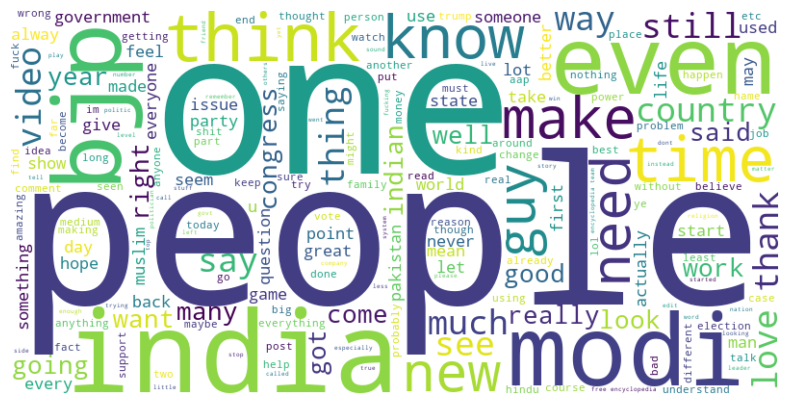

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df['clean_comment'])

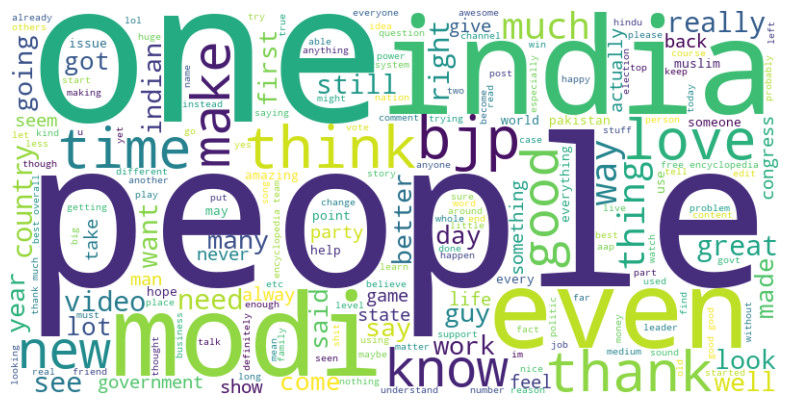

In [38]:
#Positive
plot_word_cloud(df[df['category'] == 2]['clean_comment'])

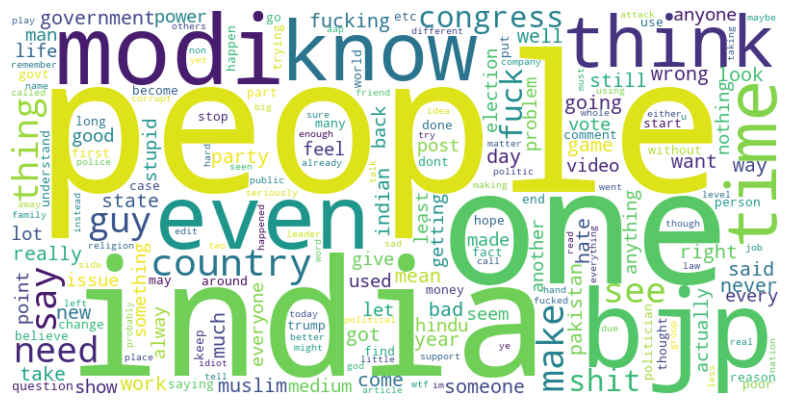

In [39]:
plot_word_cloud(df[df['category'] == 0]['clean_comment'])

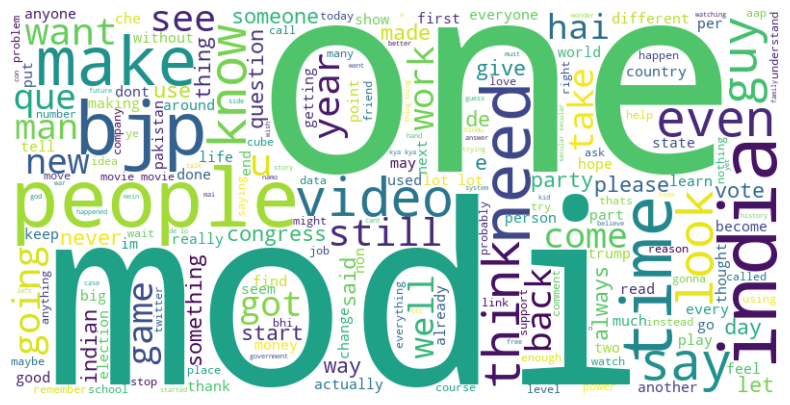

In [40]:
plot_word_cloud(df[df['category'] == 1]['clean_comment'])

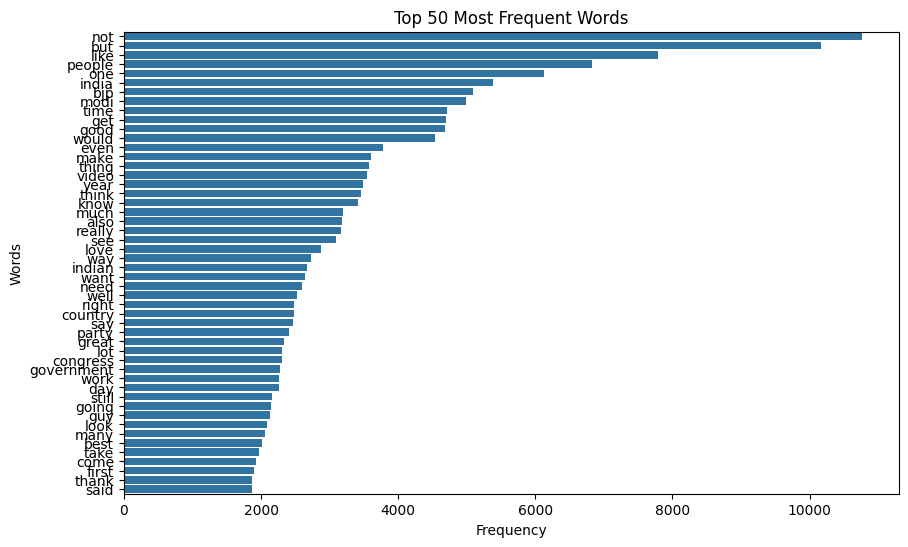

In [41]:
def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""
    words = ' '.join(df['clean_comment']).split()
    counter = Counter(words)
    most_common_words = counter.most_common(n)
    words, counts = zip(*most_common_words)

    # Plot the top N words
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

# Example usage
plot_top_n_words(df, n=50)
